In [98]:
import scanpy as sc
import pandas as pd
import squidpy as sq

import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
adata = sc.read_h5ad("/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/00_Preprocessing/data/all_samples_preprocessed_celltype_annot.h5ad")

In [100]:
adata

AnnData object with n_obs × n_vars = 167264 × 5099
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'leiden', 'cell.id', 'cell_type_oct25', 'compartment'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'cell_type_oct25_colors', 'compartment_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'log_norm', 'raw_counts'
    obsp: 'co

In [97]:
cats = adata.obs['cell_type_oct25'].cat.categories
colors = adata.uns['cell_type_oct25_colors']

for c, col in zip(cats, colors):
    print(f"{c}: {col}")

Adipocytes: #1f77b4
B_cells: #ff7f0e
Endothelial: #279e68
Epithelial: #d62728
Fibroblast: #aa40fc
Myeloid: #8c564b
PVLs: #e377c2
Plasma: #b5bd61
T_cells: #17becf


In [73]:
print(adata.obs['cell_type_oct25'].unique())

print(adata.uns['cell_type_oct25_colors'])

#['#1f77b4' '#ff7f0e' '#279e68' '#d62728' '#aa40fc' '#8c564b' '#e377c2' '#b5bd61' '#17becf']

['Epithelial', 'Myeloid', 'T_cells', 'Fibroblast', 'PVLs', 'B_cells', 'Endothelial', 'Plasma', 'Adipocytes']
Categories (9, object): ['Adipocytes', 'B_cells', 'Endothelial', 'Epithelial', ..., 'Myeloid', 'PVLs', 'Plasma', 'T_cells']
['#1f77b4' '#ff7f0e' '#279e68' '#d62728' '#aa40fc' '#8c564b' '#e377c2'
 '#b5bd61' '#17becf']


In [78]:
org_colors= ['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b', '#e377c2', '#b5bd61', '#17becf',]

In [ ]:
import random
random.shuffle(org_colors)

In [83]:
adata.uns['cell_type_oct25_colors'] = celltype_palette

In [74]:
# Set default figure size globally for matplotlib (width, height in inches)
plt.rcParams['figure.figsize'] = (16, 16)  # Adjust as needed

In [92]:
celltype_palette = {
    "Epithelial":   "#EF6F63",  # salmon red
    "T_cells":      "#D19000",  # mustard orange
    "B_cells":      "#8DAA00",  # olive green
    "Plasma":       "#00B34A",  # bright green
    "Myeloid":      "#19B394",  # teal-green
    "Endothelial":  "#1FA3C6",  # cyan-blue
    "Fibroblast":   "#5F8DD3",  # soft blue
    "PVLs":         "#B97AD9",  # lavender purple
    "Adipocytes":   "#F05BB5",  # pink
}
cats = adata.obs["cell_type_oct25"].cat.categories
adata.uns["cell_type_oct25_colors"] = [celltype_palette[c] for c in cats]

/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


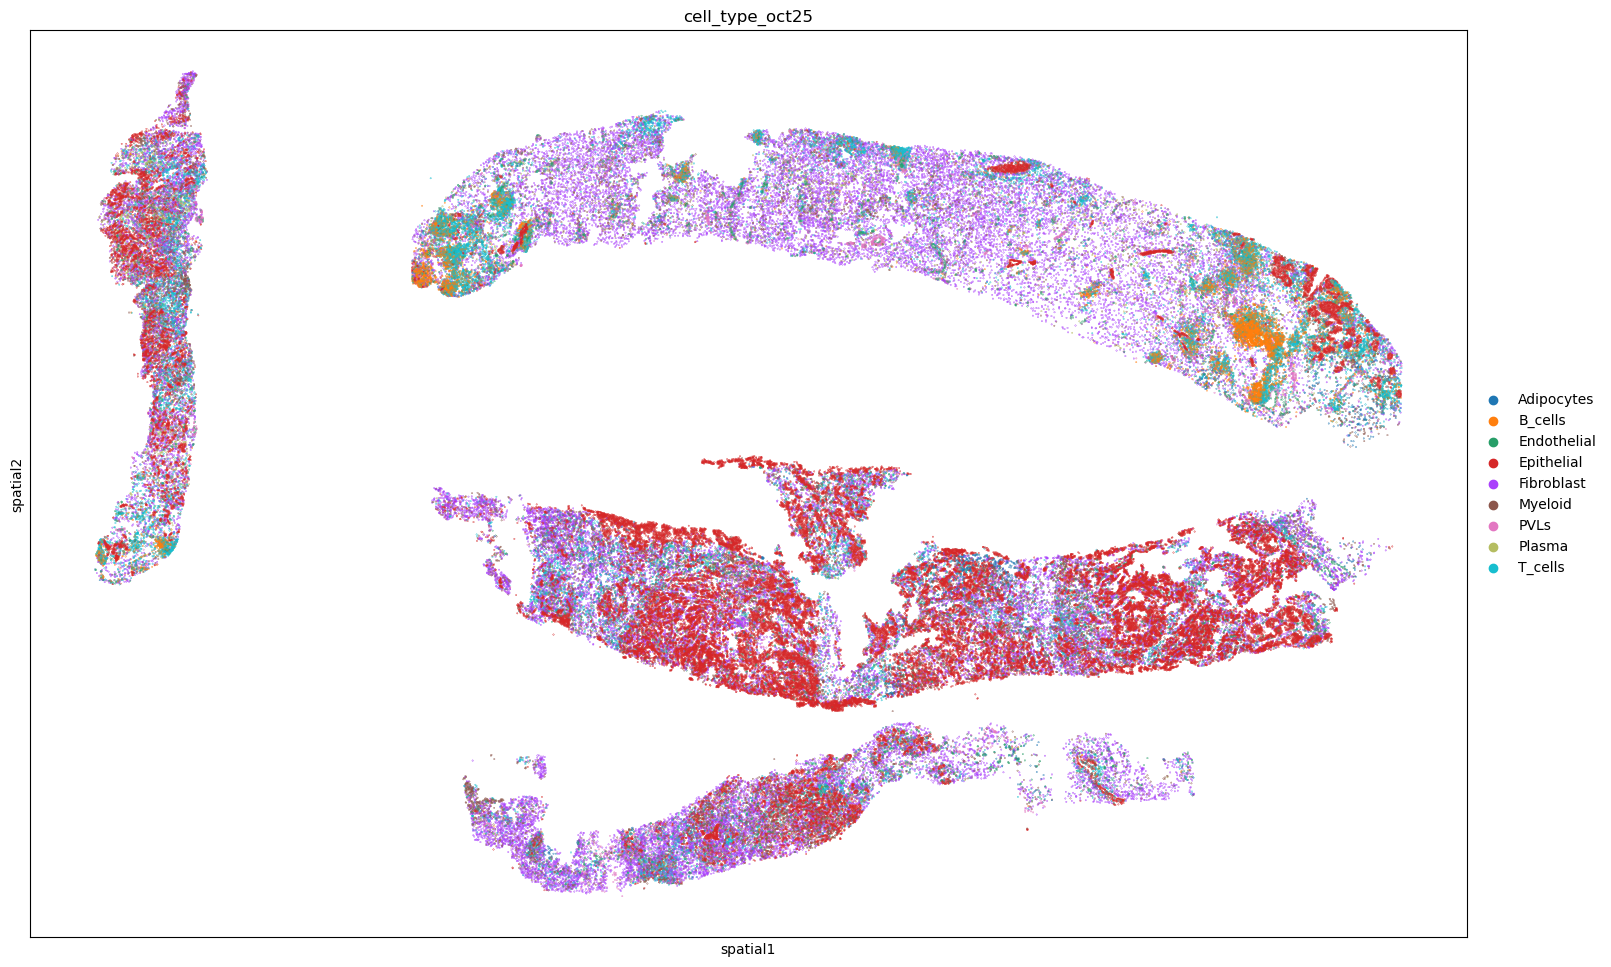

In [102]:
sq.pl.spatial_scatter(
    adata,
    color=["cell_type_oct25"],
    library_id="spatial",
    size=0.1,
    shape=None,
    save = "spatial_all_samples_cell_type_oct25_v0.png"
)

In [114]:
adata.obs['sample']

0         1105_BL
1         1105_BL
2         1105_BL
4         1105_BL
5         1105_BL
           ...   
251459    1310_V2
251460    1310_V2
251463    1310_V2
251471    1310_V2
251476    1310_V2
Name: sample, Length: 167264, dtype: category
Categories (4, object): ['1105_BL', '1105_K2', '1310_BL', '1310_V2']

In [115]:
sample_palette = {
    "1105_BL": "#F8766D",  # Patient1 BL - coral
    "1105_K2": "#7CAE00",  # Patient1 C2 - green
    "1310_BL": "#00BFC4",  # Patient2 BL - cyan
    "1310_V2": "#C77CFF",  # Patient2 C2 - purple
}

cats = adata.obs["sample"].cat.categories
adata.uns["sample_colors"] = [sample_palette[c] for c in cats]

/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


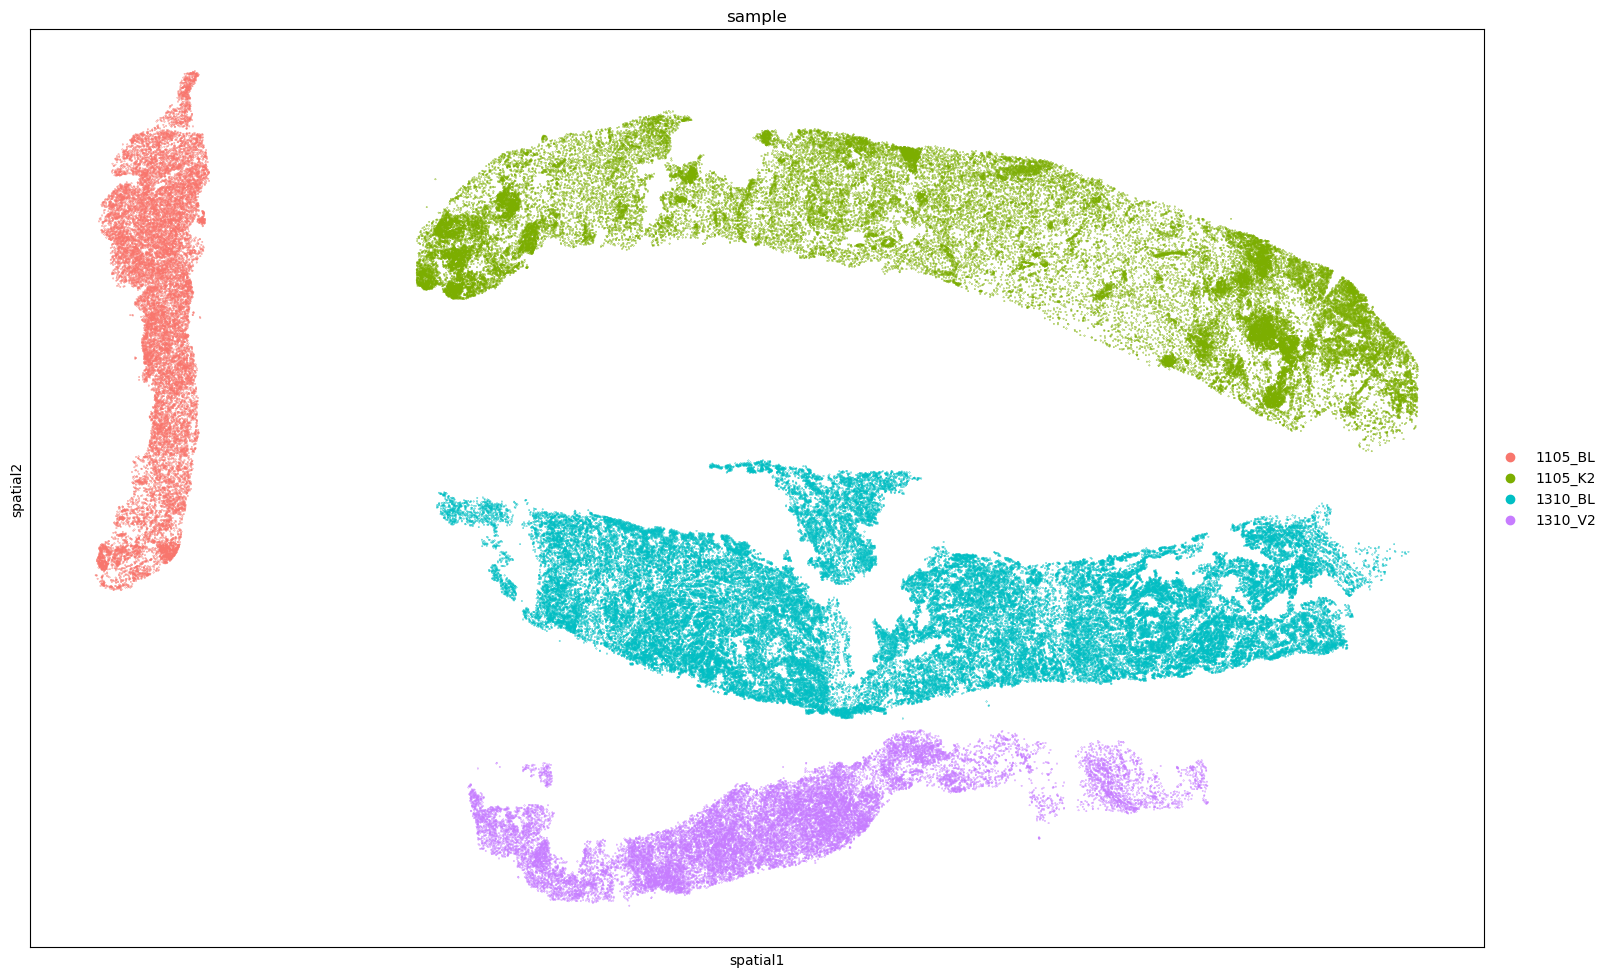

In [116]:
sq.pl.spatial_scatter(
    adata,
    color=["sample"],
    library_id="spatial",
    size=0.1,
    shape=None,
    save = "spatial_all_samples_sample.png"
)

In [117]:
adata.obs["timepoint"] = adata.obs["sample"].map({
    "1105_BL": "baseline",
    "1105_K2": "cycle2",
    "1310_BL": "baseline",
    "1310_V2": "cycle2",
}).astype("category")

In [118]:
timepoint_palette = {
    "baseline": "#F8766D",
    "cycle2":   "#00BFC4",
}

cats = adata.obs["timepoint"].cat.categories
adata.uns["timepoint_colors"] = [timepoint_palette[c] for c in cats]

/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


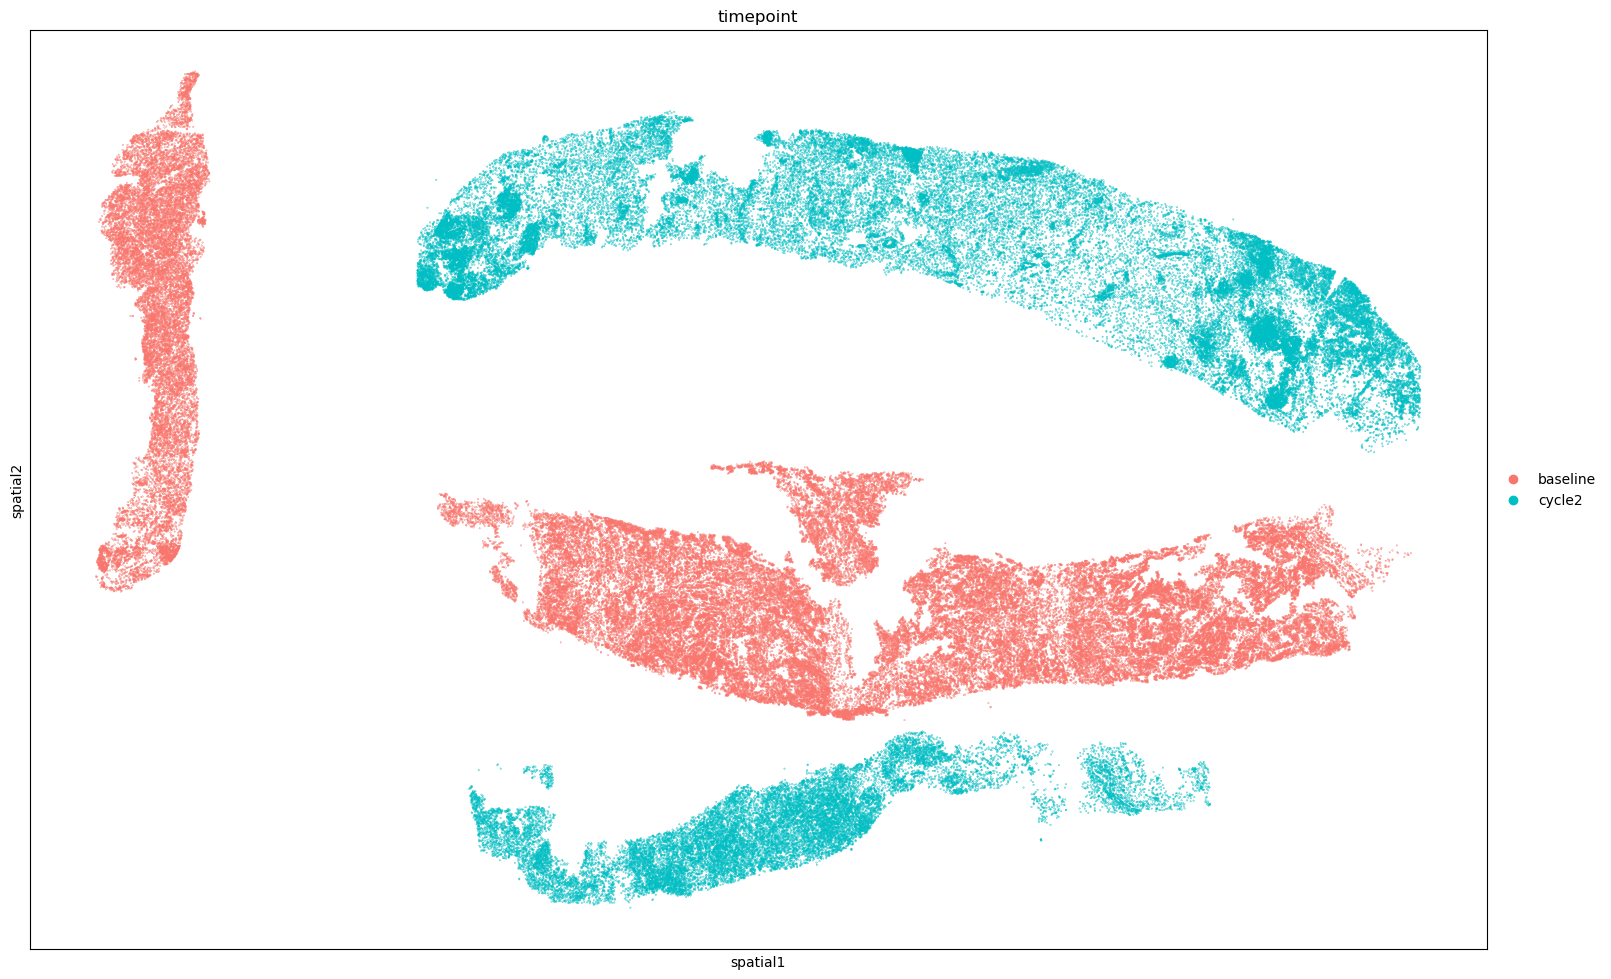

In [119]:
sq.pl.spatial_scatter(
    adata,
    color=["timepoint"],
    library_id="spatial",
    size=0.1,
    shape=None,
    save = "spatial_all_samples_timepoint.png"
)